计算excel中按类别计算特征相似度并输出基本信息

读取CSV: /home/user/prognosis_lst/evaluate_model/feature_similiary/data/huaxi/train/final_complete_with_paths.csv
总样本数: 406
类别: [0 1]
已处理 10/406 个样本
已处理 20/406 个样本
已处理 30/406 个样本
已处理 40/406 个样本
已处理 50/406 个样本
已处理 60/406 个样本
已处理 70/406 个样本
已处理 80/406 个样本
已处理 90/406 个样本
已处理 100/406 个样本
已处理 110/406 个样本
已处理 120/406 个样本
已处理 130/406 个样本
已处理 140/406 个样本
已处理 150/406 个样本
已处理 160/406 个样本
已处理 170/406 个样本
已处理 180/406 个样本
已处理 190/406 个样本
已处理 200/406 个样本
已处理 210/406 个样本
已处理 220/406 个样本
已处理 230/406 个样本
已处理 240/406 个样本
已处理 250/406 个样本
已处理 260/406 个样本
已处理 270/406 个样本
已处理 280/406 个样本
已处理 290/406 个样本
已处理 300/406 个样本
已处理 310/406 个样本
已处理 320/406 个样本
已处理 330/406 个样本
已处理 340/406 个样本
已处理 350/406 个样本
已处理 360/406 个样本
已处理 370/406 个样本
已处理 380/406 个样本


/tmp/ipykernel_684560/2548673380.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  feature = torch.load(feature_path)


已处理 390/406 个样本
已处理 400/406 个样本

各类别平均特征统计
类别 0:
  样本数: 201
  特征维度: torch.Size([400])
  特征均值: 0.1233
  特征标准差: 1.7901
  特征范围: [-4.6574, 6.2962]

类别 1:
  样本数: 205
  特征维度: torch.Size([400])
  特征均值: -0.3418
  特征标准差: 1.7951
  特征范围: [-4.8566, 4.0736]

已保存: /home/user/prognosis_lst/evaluate_model/feature_similiary/data/huaxi/class_0_average.pt
已保存: /home/user/prognosis_lst/evaluate_model/feature_similiary/data/huaxi/class_1_average.pt


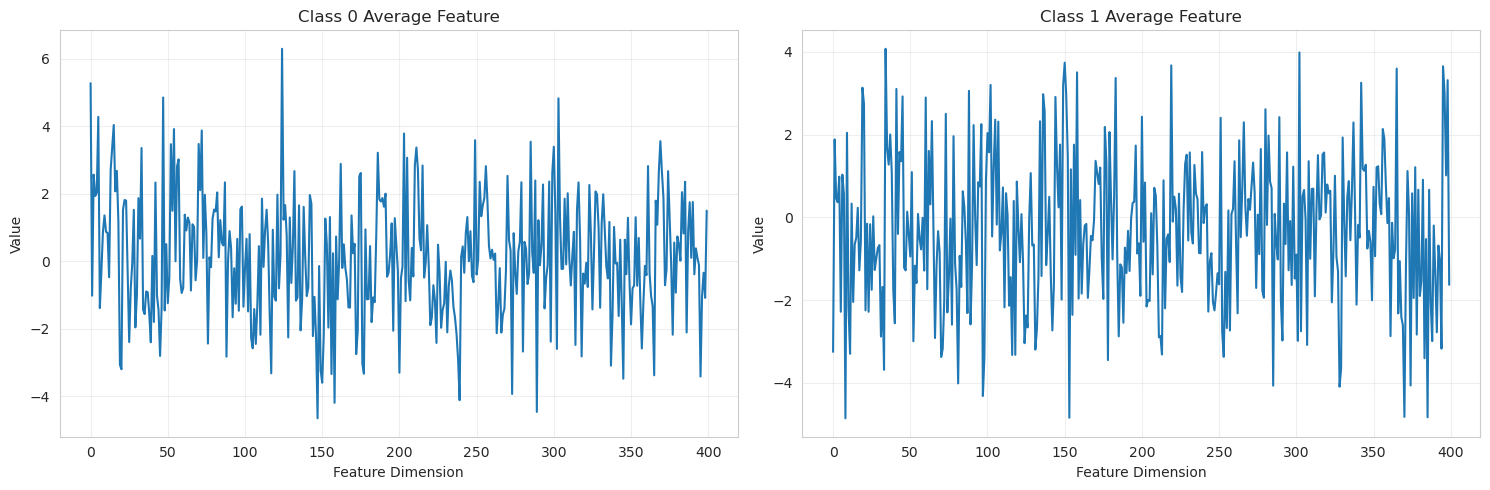

可视化已保存: class_averages_visualization.png

各类别平均特征相似度分析
类别 0 vs 类别 1:
  余弦相似度: -0.6212
  欧氏距离: 65.1345


处理完成!
类别 0: 特征维度 torch.Size([400]), 基于 2 个类别
类别 1: 特征维度 torch.Size([400]), 基于 2 个类别


In [1]:
import torch
import pandas as pd
import numpy as np
from pathlib import Path
import os

def load_and_average_features(csv_path, feature_col='feature_path', label_col='label'):

    df = pd.read_csv(csv_path)
    print(f"读取CSV: {csv_path}")
    print(f"总样本数: {len(df)}")
    
    # 获取唯一类别
    unique_labels = df[label_col].unique()
    print(f"类别: {unique_labels}")
    
    # 存储每个类别的特征
    class_features = {label: [] for label in unique_labels}
    
    # 遍历每一行，加载特征
    for idx, row in df.iterrows():
        label = row[label_col]
        feature_path = row[feature_col]
        feature = torch.load(feature_path)
        class_features[label].append(feature)        
        if (idx + 1) % 10 == 0:
            print(f"已处理 {idx+1}/{len(df)} 个样本")

    class_averages = {}
    print("\n" + "="*60)
    print("各类别平均特征统计")
    print("="*60)
    
    for label, features in class_features.items():
        if len(features) == 0:
            print(f"类别 {label}: 无有效特征")
            continue
        features_stack = torch.stack(features)
        avg_feature = features_stack.mean(dim=0)
        class_averages[label] = avg_feature
        print(f"类别 {label}:")
        print(f"  样本数: {len(features)}")
        print(f"  特征维度: {avg_feature.shape}")
        print(f"  特征均值: {avg_feature.mean():.4f}")
        print(f"  特征标准差: {avg_feature.std():.4f}")
        print(f"  特征范围: [{avg_feature.min():.4f}, {avg_feature.max():.4f}]")
        print()
    return class_averages


def save_class_averages(class_averages, output_dir='./class_averages'):

    os.makedirs(output_dir, exist_ok=True)
    
    for label, avg_feature in class_averages.items():
        # 保存为.pt文件
        output_path = os.path.join(output_dir, f'class_{label}_average.pt')
        torch.save(avg_feature, output_path)
        print(f"已保存: {output_path}")
        

def visualize_class_averages(class_averages):
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, len(class_averages), figsize=(15, 5))
    for i, (label, avg_feature) in enumerate(class_averages.items()):
        ax = axes[i] if len(class_averages) > 1 else axes
        
        # 绘制特征向量
        ax.plot(avg_feature.numpy())
        ax.set_title(f'Class {label} Average Feature')
        ax.set_xlabel('Feature Dimension')
        ax.set_ylabel('Value')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('class_averages_visualization.png')
    plt.show()
    print("可视化已保存: class_averages_visualization.png")


def analyze_class_similarity(class_averages):

    import torch.nn.functional as F
    
    labels = list(class_averages.keys())
    n_classes = len(labels)
    
    print("\n" + "="*60)
    print("各类别平均特征相似度分析")
    print("="*60)
    
    for i in range(n_classes):
        for j in range(i+1, n_classes):
            label1 = labels[i]
            label2 = labels[j]
            
            feat1 = class_averages[label1]
            feat2 = class_averages[label2]
            
            # 余弦相似度
            cos_sim = F.cosine_similarity(feat1.unsqueeze(0), feat2.unsqueeze(0)).item()
            
            # 欧氏距离
            euclidean_dist = torch.dist(feat1, feat2, p=2).item()
            
            print(f"类别 {label1} vs 类别 {label2}:")
            print(f"  余弦相似度: {cos_sim:.4f}")
            print(f"  欧氏距离: {euclidean_dist:.4f}")
            print()


def main():
    # CSV文件路径
    csv_path = "/home/user/prognosis_lst/evaluate_model/feature_similiary/data/huaxi/train/final_complete_with_paths.csv"  # 替换为你的CSV文件路径
    
    # 1. 计算各类别的平均特征
    class_averages = load_and_average_features(
        csv_path=csv_path,
        feature_col='feature_path',
        label_col='label'
    )
    
    # 2. 保存平均特征
    save_class_averages(class_averages, output_dir="/home/user/prognosis_lst/evaluate_model/feature_similiary/data/huaxi")
    
    # 3. 可视化（可选）
    visualize_class_averages(class_averages)
    
    # 4. 分析类别间相似度
    analyze_class_similarity(class_averages)
    
    # 5. 打印总结
    print("\n" + "="*60)
    print("处理完成!")
    print("="*60)
    for label, avg_feature in class_averages.items():
        print(f"类别 {label}: 特征维度 {avg_feature.shape}, 基于 {len(class_averages)} 个类别")


if __name__ == "__main__":
    main()

计算单pt和对应而excel中所有样本的相似度

In [2]:
import torch
import torch.nn.functional as F
import pandas as pd
import os
from tqdm import tqdm

def add_similarity_column(target_path, csv_path, output_path=None):
    target = torch.load(target_path)
    if target.dim() > 1:
        target = target.view(-1)
    target = target.unsqueeze(0)
    
    # 读取CSV
    df = pd.read_csv(csv_path)
    
    # 计算相似度
    similarities = []
    for path in tqdm(df['feature_path'], desc="计算相似度"):
        feat = torch.load(path)
        feat = feat.unsqueeze(0)
        sim = F.cosine_similarity(target, feat).item()
        similarities.append(sim)

    # 添加列
    target_name = os.path.basename(target_path).replace('.pt', '')
    df[f'similarity_to_{target_name}'] = similarities
    
    # 保存
    if output_path is None:
        output_path = csv_path.replace('.csv', f'_with_similarity.csv')
    
    df.to_csv(output_path, index=False)
    print(f"结果已保存到: {output_path}")
    
    return df

# 使用
target = '/home/user/prognosis_lst/feature/huaxi/train/004e8a14335ab457e9c50fee56691e72.pt'
csv = "/home/user/prognosis_lst/evaluate_model/feature_similiary/data/huaxi/train/final_complete_with_paths.csv"

df_with_sim = add_similarity_column(target, csv)

/tmp/ipykernel_684560/3665637017.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  target = torch.load(target_path)
计算相似度:   0%|          | 0/406 [00:00<?, ?it/s]/tmp/ipyk

结果已保存到: /home/user/prognosis_lst/evaluate_model/feature_similiary/data/huaxi/train/final_complete_with_paths_with_similarity.csv


计算俩个特征中心的相似度

In [3]:
import torch
import torch.nn.functional as F
import numpy as np

def print_feature_stats(feature, name="特征"):
    """打印特征的基本统计信息"""
    f_np = feature.cpu().numpy() if feature.is_cuda else feature.numpy()
    
    print(f"\n{name}:")
    print(f"  形状: {feature.shape}")
    print(f"  均值: {f_np.mean():.6f}")
    print(f"  标准差: {f_np.std():.6f}")
    print(f"  最小值: {f_np.min():.6f}")
    print(f"  最大值: {f_np.max():.6f}")
    print(f"  范围: [{f_np.min():.6f}, {f_np.max():.6f}]")

# 加载特征
feature1 = torch.load('/home/user/prognosis_lst/evaluate_model/feature_similiary/data/huaxi/class_0_average.pt')
feature2 = torch.load('/home/user/prognosis_lst/evaluate_model/feature_similiary/data/huaxi/class_1_average.pt')

# 确保是一维
if feature1.dim() > 1:
    feature1 = feature1.view(-1)
if feature2.dim() > 1:
    feature2 = feature2.view(-1)

# 打印统计信息
print_feature_stats(feature1, "Class 0 平均特征")
print_feature_stats(feature2, "Class 1 平均特征")

# 计算余弦相似度
cosine_similarity = F.cosine_similarity(feature1.unsqueeze(0), feature2.unsqueeze(0))
print(f"\n余弦相似度: {cosine_similarity.item():.6f}")


Class 0 平均特征:
  形状: torch.Size([400])
  均值: 0.123278
  标准差: 1.787849
  最小值: -4.657421
  最大值: 6.296233
  范围: [-4.657421, 6.296233]

Class 1 平均特征:
  形状: torch.Size([400])
  均值: -0.341810
  标准差: 1.792875
  最小值: -4.856628
  最大值: 4.073565
  范围: [-4.856628, 4.073565]

余弦相似度: -0.621155


/tmp/ipykernel_684560/1112098406.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  feature1 = torch.load('/home/user/prognosis_lst/evaluate_model/feature_similiary/data/h

## 每个中心点与train中的相同类别计算相似度，并统计均值方差等

In [4]:
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import os
from tqdm import tqdm

def calculate_class_similarity(class_average_path, csv_path, class_label=0):

    # 1. 加载类别平均特征
    print(f"加载类别平均特征: {class_average_path}")
    class_avg = torch.load(class_average_path)
    

    # 2. 读取CSV文件
    print(f"读取CSV文件: {csv_path}")
    df = pd.read_csv(csv_path)
    print(f"总样本数: {len(df)}")
    
    # 3. 筛选指定类别的样本
    df_class = df[df['label'] == class_label].copy()
    print(f"类别 {class_label} 样本数: {len(df_class)}")
    
    if len(df_class) == 0:
        print(f"警告: 类别 {class_label} 没有样本")
        return df_class, {}
    
    # 4. 计算每个样本与类别平均特征的余弦相似度
    similarities = []
    valid_indices = []
    
    for idx, row in tqdm(df_class.iterrows(), total=len(df_class), desc=f"计算类别{class_label}相似度"):
        feat_path = row['feature_path']
        # 加载特征
        feat = torch.load(feat_path)
        # 计算余弦相似度
        sim = F.cosine_similarity(class_avg.unsqueeze(0), feat.unsqueeze(0)).item()
        similarities.append(sim)
        valid_indices.append(idx)

    # 5. 将相似度添加到DataFrame
    df_class.loc[valid_indices, 'similarity'] = similarities
    
    # 6. 统计信息
    sim_array = np.array(similarities)
    
    stats = {
        'class': class_label,
        'count': len(sim_array),
        'mean': np.mean(sim_array),
        'std': np.std(sim_array),
        'min': np.min(sim_array),
        'max': np.max(sim_array),
        'median': np.median(sim_array),
        'q1': np.percentile(sim_array, 25),
        'q3': np.percentile(sim_array, 75),
        'iqr': np.percentile(sim_array, 75) - np.percentile(sim_array, 25),
        'p5': np.percentile(sim_array, 5),
        'p95': np.percentile(sim_array, 95),
    }
    
    # 打印统计信息
    print("\n" + "="*50)
    print(f"类别 {class_label} 相似度统计")
    print("="*50)
    print(f"样本数量: {stats['count']}")
    print(f"均值 (mean): {stats['mean']:.6f}")
    print(f"标准差 (std): {stats['std']:.6f}")
    print(f"最小值 (min): {stats['min']:.6f}")
    print(f"最大值 (max): {stats['max']:.6f}")
    print(f"中位数 (median): {stats['median']:.6f}")
    print(f"第一四分位数 (Q1): {stats['q1']:.6f}")
    print(f"第三四分位数 (Q3): {stats['q3']:.6f}")
    print(f"四分位距 (IQR): {stats['iqr']:.6f}")
    print(f"5% 分位数: {stats['p5']:.6f}")
    print(f"95% 分位数: {stats['p95']:.6f}")
    
    return df_class, stats

def calculate_both_classes(class_0_path, class_1_path, csv_path,out_path):
    """
    计算类别0和类别1的相似度统计
    """
    print("="*60)
    print("计算两个类别的相似度统计")
    print("="*60)
    
    # 计算类别0
    df_class0, stats0 = calculate_class_similarity(class_0_path, csv_path, class_label=0)
    
    print("\n")
    
    # 计算类别1
    df_class1, stats1 = calculate_class_similarity(class_1_path, csv_path, class_label=1)
    
    # 保存结果
    output_path0 = os.path.join(out_path, 'class0_with_similarity.csv')
    output_path1 = os.path.join(out_path,'class1_with_similarity.csv')
    
    df_class0.to_csv(output_path0, index=False)
    df_class1.to_csv(output_path1, index=False)
    
    print(f"\n类别0结果已保存: {output_path0}")
    print(f"类别1结果已保存: {output_path1}")
    

    
    return df_class0,df_class1



# 使用示例
if __name__ == "__main__":
    # 文件路径
    class_0_path = '/home/user/prognosis_lst/evaluate_model/feature_similiary/data/huaxi/class_0_average.pt'
    class_1_path = '/home/user/prognosis_lst/evaluate_model/feature_similiary/data/huaxi/class_1_average.pt'  # 如果有类别1的平均特征
    csv_path = "/home/user/prognosis_lst/evaluate_model/feature_similiary/data/huaxi/train/final_complete_with_paths.csv"
    df_class0,df_class1 = calculate_both_classes(class_0_path, class_1_path, csv_path,"./")

/tmp/ipykernel_684560/168410712.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  class_avg = torch.load(class_average_path)


计算两个类别的相似度统计
加载类别平均特征: /home/user/prognosis_lst/evaluate_model/feature_similiary/data/huaxi/class_0_average.pt
读取CSV文件: /home/user/prognosis_lst/evaluate_model/feature_similiary/data/huaxi/train/final_complete_with_paths.csv
总样本数: 406
类别 0 样本数: 201


计算类别0相似度:   0%|          | 0/201 [00:00<?, ?it/s]/tmp/ipykernel_684560/168410712.py:35: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  feat = torch.load(feat_path)
计算类别0相似度: 


类别 0 相似度统计
样本数量: 201
均值 (mean): 0.832611
标准差 (std): 0.143141
最小值 (min): 0.107909
最大值 (max): 0.974334
中位数 (median): 0.881237
第一四分位数 (Q1): 0.785900
第三四分位数 (Q3): 0.917102
四分位距 (IQR): 0.131202
5% 分位数: 0.569536
95% 分位数: 0.948633


加载类别平均特征: /home/user/prognosis_lst/evaluate_model/feature_similiary/data/huaxi/class_1_average.pt
读取CSV文件: /home/user/prognosis_lst/evaluate_model/feature_similiary/data/huaxi/train/final_complete_with_paths.csv
总样本数: 406
类别 1 样本数: 205


计算类别1相似度:   0%|          | 0/205 [00:00<?, ?it/s]/tmp/ipykernel_684560/168410712.py:35: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  feat = torch.load(feat_path)
计算类别1相似度: 


类别 1 相似度统计
样本数量: 205
均值 (mean): 0.787413
标准差 (std): 0.295031
最小值 (min): -0.485357
最大值 (max): 0.973166
中位数 (median): 0.883365
第一四分位数 (Q1): 0.792394
第三四分位数 (Q3): 0.926512
四分位距 (IQR): 0.134118
5% 分位数: -0.037978
95% 分位数: 0.958437

类别0结果已保存: ./class0_with_similarity.csv
类别1结果已保存: ./class1_with_similarity.csv


## 计算之要选取阈值筛27w数据

In [5]:
import torch
import torch.nn.functional as F
import pandas as pd
import os
import numpy as np
from tqdm import tqdm

def add_similarity_column(target_path, csv_path, output_path=None): 
    # 加载目标特征
    target = torch.load(target_path) 
    if target.dim() > 1: 
        target = target.view(-1) 
    target = target.unsqueeze(0) # [1, D]
    
    # 读取CSV
    df = pd.read_csv(csv_path) 
    
    # 计算相似度
    similarities = [] 
    for path in tqdm(df['feature_path'], desc="计算相似度"): 
        feat = torch.load(path) 
        if feat.dim() > 1:
            feat = feat.view(-1)
        feat = feat.unsqueeze(0) # [1, D]
        
        # 计算余弦相似度
        sim = F.cosine_similarity(target, feat).item() 
        similarities.append(sim) 

    # 添加相似度列
    target_name = os.path.basename(target_path).replace('.pt', '') 
    col_name = f'similarity_to_{target_name}'
    df[col_name] = similarities
    
    # --- 新增：统计信息计算 ---
    stats = {
        "Mean (均值)": df[col_name].mean(),
        "Median (中位数)": df[col_name].median(),
        "Std Dev (标准差)": df[col_name].std(),
        "Variance (方差)": df[col_name].var(),
        "Min (最小值)": df[col_name].min(),
        "Max (最大值)": df[col_name].max(),
        "Q1 (25%分位数)": df[col_name].quantile(0.25),
        "Q3 (75%分分数)": df[col_name].quantile(0.75)
    }

    # 打印报表
    print("\n" + "="*30)
    print(f"相似度统计报告: {target_name}")
    print("-"*30)
    for k, v in stats.items():
        print(f"{k:<15}: {v:.6f}")
    print("="*30 + "\n")
    
    # --- 保存结果 ---
    if output_path is None: 
        output_path = csv_path.replace('.csv', f'_with_similarity.csv') 
    else:
        # 如果指定的输出路径没有csv后缀，补上
        if not output_path.endswith('.csv'):
            output_path += ".csv"
            
    # 保存详细CSV
    df.to_csv(output_path, index=False) 
    
    # 保存统计摘要到文本文件
    summary_path = output_path.replace('.csv', '_summary.txt')
    with open(summary_path, 'w', encoding='utf-8') as f:
        f.write(f"Target Feature: {target_path}\n")
        f.write(f"Source CSV: {csv_path}\n")
        f.write("-" * 40 + "\n")
        for k, v in stats.items():
            f.write(f"{k}: {v:.6f}\n")
            
    print(f"详细结果已保存到: {output_path}") 
    print(f"统计摘要已保存到: {summary_path}") 
    
    return df, stats

# --- 参数配置 ---
target_file = '/home/user/prognosis_lst/evaluate_model/feature_similiary/data/huaxi/class_0_average.pt' 
source_csv = "/home/user/prognosis_lst/evaluate_model/feature_similiary/data/huaxi/pretrain/final_complete_with_paths.csv" 
# 注意：这里建议给一个完整的文件名或目录前缀
output_file = "/home/user/prognosis_lst/evaluate_model/feature_similiary/huaxi/pretrain_class_0_sim.csv" 

# 执行
df_result, summary_stats = add_similarity_column(target_file, source_csv, output_file)

/tmp/ipykernel_684560/1628077987.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  target = torch.load(target_path)
计算相似度:   0%|          | 0/266761 [00:00<?, ?it/s]/tmp/


相似度统计报告: class_0_average
------------------------------
Mean (均值)      : 0.103418
Median (中位数)   : 0.101235
Std Dev (标准差)  : 0.323092
Variance (方差)  : 0.104388
Min (最小值)      : -0.748536
Max (最大值)      : 0.931389
Q1 (25%分位数)    : -0.150685
Q3 (75%分分数)    : 0.358712

详细结果已保存到: /home/user/prognosis_lst/evaluate_model/feature_similiary/huaxi/pretrain_class_0_sim.csv
统计摘要已保存到: /home/user/prognosis_lst/evaluate_model/feature_similiary/huaxi/pretrain_class_0_sim_summary.txt


In [6]:
import torch
import torch.nn.functional as F
import pandas as pd
import os
import numpy as np
from tqdm import tqdm

def add_similarity_column(target_path, csv_path, output_path=None): 
    # 加载目标特征
    target = torch.load(target_path) 
    if target.dim() > 1: 
        target = target.view(-1) 
    target = target.unsqueeze(0) # [1, D]
    
    # 读取CSV
    df = pd.read_csv(csv_path) 
    
    # 计算相似度
    similarities = [] 
    for path in tqdm(df['feature_path'], desc="计算相似度"): 
        feat = torch.load(path) 
        if feat.dim() > 1:
            feat = feat.view(-1)
        feat = feat.unsqueeze(0) # [1, D]
        
        # 计算余弦相似度
        sim = F.cosine_similarity(target, feat).item() 
        similarities.append(sim) 

    # 添加相似度列
    target_name = os.path.basename(target_path).replace('.pt', '') 
    col_name = f'similarity_to_{target_name}'
    df[col_name] = similarities
    
    # --- 新增：统计信息计算 ---
    stats = {
        "Mean (均值)": df[col_name].mean(),
        "Median (中位数)": df[col_name].median(),
        "Std Dev (标准差)": df[col_name].std(),
        "Variance (方差)": df[col_name].var(),
        "Min (最小值)": df[col_name].min(),
        "Max (最大值)": df[col_name].max(),
        "Q1 (25%分位数)": df[col_name].quantile(0.25),
        "Q3 (75%分分数)": df[col_name].quantile(0.75)
    }

    # 打印报表
    print("\n" + "="*30)
    print(f"相似度统计报告: {target_name}")
    print("-"*30)
    for k, v in stats.items():
        print(f"{k:<15}: {v:.6f}")
    print("="*30 + "\n")
    
    # --- 保存结果 ---
    if output_path is None: 
        output_path = csv_path.replace('.csv', f'_with_similarity.csv') 
    else:
        # 如果指定的输出路径没有csv后缀，补上
        if not output_path.endswith('.csv'):
            output_path += ".csv"
            
    # 保存详细CSV
    df.to_csv(output_path, index=False) 
    
    # 保存统计摘要到文本文件
    summary_path = output_path.replace('.csv', '_summary.txt')
    with open(summary_path, 'w', encoding='utf-8') as f:
        f.write(f"Target Feature: {target_path}\n")
        f.write(f"Source CSV: {csv_path}\n")
        f.write("-" * 40 + "\n")
        for k, v in stats.items():
            f.write(f"{k}: {v:.6f}\n")
            
    print(f"详细结果已保存到: {output_path}") 
    print(f"统计摘要已保存到: {summary_path}") 
    
    return df, stats

# --- 参数配置 ---
target_file = '/home/user/prognosis_lst/evaluate_model/feature_similiary/data/huaxi/class_1_average.pt' 
source_csv = "/home/user/prognosis_lst/evaluate_model/feature_similiary/data/huaxi/pretrain/final_complete_with_paths.csv" 
# 注意：这里建议给一个完整的文件名或目录前缀
output_file = "/home/user/prognosis_lst/evaluate_model/feature_similiary/huaxi/pretrain_class_1_sim.csv" 

# 执行
df_result, summary_stats = add_similarity_column(target_file, source_csv, output_file)

/tmp/ipykernel_684560/1453411845.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  target = torch.load(target_path)
计算相似度:   0%|          | 0/266761 [00:00<?, ?it/s]/tmp/


相似度统计报告: class_1_average
------------------------------
Mean (均值)      : -0.000664
Median (中位数)   : -0.019425
Std Dev (标准差)  : 0.334898
Variance (方差)  : 0.112157
Min (最小值)      : -0.735351
Max (最大值)      : 0.964327
Q1 (25%分位数)    : -0.266216
Q3 (75%分分数)    : 0.237166

详细结果已保存到: /home/user/prognosis_lst/evaluate_model/feature_similiary/huaxi/pretrain_class_1_sim.csv
统计摘要已保存到: /home/user/prognosis_lst/evaluate_model/feature_similiary/huaxi/pretrain_class_1_sim_summary.txt


In [10]:
#合并俩个csvh
import pandas as pd

# 读取两个CSV文件
df_class0 = pd.read_csv('/home/user/prognosis_lst/evaluate_model/feature_similiary/huaxi/pretrain_class_0_sim.csv')  # 包含 similarity_to_class_0_average
df_class1 = pd.read_csv('/home/user/prognosis_lst/evaluate_model/feature_similiary/huaxi/pretrain_class_1_sim.csv')  # 包含 similarity_to_class_1_average

# 合并两个相似度列
# 假设两个文件的行顺序一致，直接添加列
df_combined = df_class0.copy()
df_combined['similarity_to_class_1_average'] = df_class1['similarity_to_class_1_average']

# 或者按 feature_path 合并（更稳健）
# df_combined = pd.merge(df_class0, df_class1[['feature_path', 'similarity_to_class_1_average']], on='feature_path', how='left')

# 保存合并后的文件
df_combined.to_csv('/home/user/prognosis_lst/evaluate_model/feature_similiary/huaxi/pretrain_class_sim.csv', index=False)
print(f"合并后的文件已保存: /home/user/prognosis_lst/evaluate_model/feature_similiary/huaxi/pretrain_class_sim.csv")
print(f"总行数: {len(df_combined)}")
print(f"列名: {df_combined.columns.tolist()}")

合并后的文件已保存: /home/user/prognosis_lst/evaluate_model/feature_similiary/huaxi/pretrain_class_sim.csv
总行数: 266761
列名: ['feature_path', 'label', 'similarity_to_class_0_average', 'similarity_to_class_1_average']


## 这是一个分层递进的伪标签分配策略
我有一个新的数据集，在计算完与每个类别中心的距离后，该怎么操作分配伪标签，想法是分几个情况，设计俩个类别阈值1，如果大于某一个直接分配为标签，如果大于俩个，则不分配伪标签，小于俩个也不分配，之后对剩下的没有分配为标签的继续处理，设置俩个类别阈值2（小于类别阈值1），如果大于某一个，与该类别的特征进行拉近，然后分配伪标签，都大于则看更接近哪一个，进行特征拉近分配伪标签，小于的话则不进行处理，这个想法咋样，应该怎么设置阈值，特征拉近思路有什么好的想法嘛

In [11]:
import numpy as np
import torch
import torch.nn.functional as F


def calculate_thresholds(stats0, stats1, method='percentile'):

    if method == 'percentile':
        # 使用Q1作为阈值2，Q3作为阈值1
        threshold1_0 = stats0['q3']  # 类别0的高阈值
        threshold2_0 = stats0['q1']  # 类别0的低阈值
        
        threshold1_1 = stats1['q3']  # 类别1的高阈值
        threshold2_1 = stats1['q1']  # 类别1的低阈值
        
    elif method == 'mean_std':
        # 使用均值±标准差
        threshold1_0 = stats0['mean'] + 0.5 * stats0['std']
        threshold2_0 = stats0['mean'] - 0.5 * stats0['std']
        
        threshold1_1 = stats1['mean'] + 0.5 * stats1['std']
        threshold2_1 = stats1['mean'] - 0.5 * stats1['std']
    
    return threshold1_0, threshold1_1, threshold2_0, threshold2_1

# 使用你的统计信息
stats0 = {
    'mean': 0.832611, 'std': 0.143141, 'q1': 0.785900, 'q3': 0.917102
}
stats1 = {
    'mean': 0.787413, 'std': 0.295031, 'q1': 0.792394, 'q3': 0.926512
}  # 假设类别1有类似统计

th1_0, th1_1, th2_0, th2_1 = calculate_thresholds(stats0, stats1, method='percentile')
print(f"{th1_0,th2_0}")
print(f"{th1_1,th2_1}")

(0.917102, 0.7859)
(0.926512, 0.792394)


In [12]:
## 加权特征拉近，考虑一下最低类别0，至少大于60才能进来，少于0.8，假设是0.7，，

def feature_pull(feature, target_feature, similarity, threshold1,threshold2,pull_strength=0.5):
    """
    将特征向目标中心拉近
    
    Args:
        feature: 当前特征
        target_feature: 目标类别中心特征
        similarity: 当前相似度
        threshold: 阈值2
        pull_strength: 拉近强度（0-1）
    """
    # 计算需要拉近的程度（相似度离阈值越远，拉得越多）pull这个值最低为0，最高可能为0.815-0.60 = 0.215/0.4=0.5，，当pull=1时，限制在了0和0.5直接，
    pull_factor = (threshold1 - similarity) / (threshold1 - threshold2) * pull_strength   
    pull_factor = np.clip(pull_factor, 0, 0.5)  # 限制最大拉近程度
    
    # 加权平均拉近
    pulled_feature = (1 - pull_factor) * feature + pull_factor * target_feature
    
    return pulled_feature, pull_factor



In [13]:
feature1 = torch.load("/home/user/prognosis_lst/feature/huaxi/pretrain/train/00c781d0e4fad276c5d1fad3b3c3150b.pt")
##这个特征是类别0的0.608，看一下拉近之后变成多少z缩放系数应该最大为0.5s
feature2 = torch.load("/home/user/prognosis_lst/evaluate_model/feature_similiary/data/huaxi/class_0_average.pt")
print(F.cosine_similarity(feature1.unsqueeze(0), feature2.unsqueeze(0)).item() )
a,b = feature_pull(feature1,feature2,0.70937,0.918124,0.682307)

-0.5703549385070801


/tmp/ipykernel_684560/2874482865.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  feature1 = torch.load("/home/user/prognosis_lst/feature/huaxi/pretrain/train/00c781d0e4f

In [14]:
b

0.44261864072564755

In [15]:
print(F.cosine_similarity(a.unsqueeze(0), feature2.unsqueeze(0)).item() )
##拉完之后的相似度l

0.4589093327522278


In [16]:
##整体参数的选取要将第三分位数的拉到第一分位数即可，这个要控制strength的参数手调s，参数最终选的0.4之后进行筛选符合特征的csv，保存一遍置信度，

## 整体思确定好了，扫一遍csv，保留需要保存的，并留feature_path，生成的伪标签为labl，以及新建一列相似度保留与伪标签的相似度，再来一列是否做特征拉近，阈值为以下代码输出的阈值，

In [17]:
import numpy as np
import torch
import torch.nn.functional as F

def calculate_thresholds(stats0, stats1, method='percentile'):

    if method == 'percentile':
        # 使用Q1作为阈值2，Q3作为阈值1
        threshold1_0 = stats0['q3']  # 类别0的高阈值
        threshold2_0 = stats0['q1']  # 类别0的低阈值
        
        threshold1_1 = stats1['q3']  # 类别1的高阈值
        threshold2_1 = stats1['q1']  # 类别1的低阈值
        
    elif method == 'mean_std':
        # 使用均值±标准差
        threshold1_0 = stats0['mean'] + 0.5 * stats0['std']
        threshold2_0 = stats0['mean'] - 0.5 * stats0['std']
        
        threshold1_1 = stats1['mean'] + 0.5 * stats1['std']
        threshold2_1 = stats1['mean'] - 0.5 * stats1['std']
    
    return threshold1_0, threshold1_1, threshold2_0, threshold2_1

# 使用你的统计信息
stats0 = {
    'mean': 0.832611, 'std': 0.143141, 'q1': 0.785900, 'q3': 0.917102
}
stats1 = {
    'mean': 0.787413, 'std': 0.295031, 'q1': 0.792394, 'q3': 0.926512
}  # 假设类别1有类似统计
# 加载数据
df = pd.read_csv('/home/user/prognosis_lst/evaluate_model/feature_similiary/huaxi/pretrain_class_sim.csv')

# 分配伪标签
results = []
for _, row in tqdm(df.iterrows(), total=len(df)):
    sim0, sim1 = row['similarity_to_class_0_average'], row['similarity_to_class_1_average']
    
    # 判断逻辑
    if sim0 > th1_0 and sim1 <= th1_1:
        label, level, pull = 0, 'high', False
    elif sim1 > th1_1 and sim0 <= th1_0:
        label, level, pull = 1, 'high', False
    
    # 情况2: 都高于第一分位数 - 舍弃
    elif sim0 > th1_0 and sim1 > th1_1:
        continue  # 舍弃
    
    # 情况3: 中置信度 - 至少有一个高于第二分位数（阈值2）
    else:
        # 都低于第二分位数 - 舍弃
        if sim0 <= th2_0 and sim1 <= th2_1:
            continue  # 舍弃
        
        # 只有一个高于第二分位数
        elif sim0 > th2_0 and sim1 <= th2_1:
            label, level, pull = 0, 'medium', True
        elif sim1 > th2_1 and sim0 <= th2_0:
            label, level, pull = 1, 'medium', True
        
        # 都高于第二分位数 - 看离哪个近
        elif sim0 > th2_0 and sim1 > th2_1:
            label = 0 if sim0 > sim1 else 1
            level, pull = 'medium-close', True
    
    results.append({
        'feature_path': row['feature_path'],
        'label': label,
        'need_pull': pull,
        'sim_to_pseudo': sim0 if label == 0 else sim1,
    })

# 保存结果
df_result = pd.DataFrame(results)
df_result.to_csv('/home/user/prognosis_lst/evaluate_model/feature_similiary/huaxi/pseudo_label_results.csv', index=False)
print(f"保存了 {len(df_result)} 个样本")

100%|██████████| 266761/266761 [00:05<00:00, 50974.87it/s]

保存了 4287 个样本
